# **Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [2]:
df = pd.read_csv('data/raw/framingham.csv')
df_processed = df.copy()

numerical_cols = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
categorical_cols = ['education', 'BPMeds']

In [3]:
# Fill missing values
num_imputer = SimpleImputer(strategy='median')
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = num_imputer.fit_transform(df_processed[[col]])

cat_imputer = SimpleImputer(strategy='most_frequent')
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = cat_imputer.fit_transform(df_processed[[col]])

TenYearCHD         1.000000
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.121319
diabetes           0.097344
male               0.088374
BPMeds             0.086448
totChol            0.081749
BMI                0.074326
prevalentStroke    0.061823
cigsPerDay         0.058729
heartRate          0.022851
currentSmoker      0.019448
education         -0.053002
Name: TenYearCHD, dtype: float64


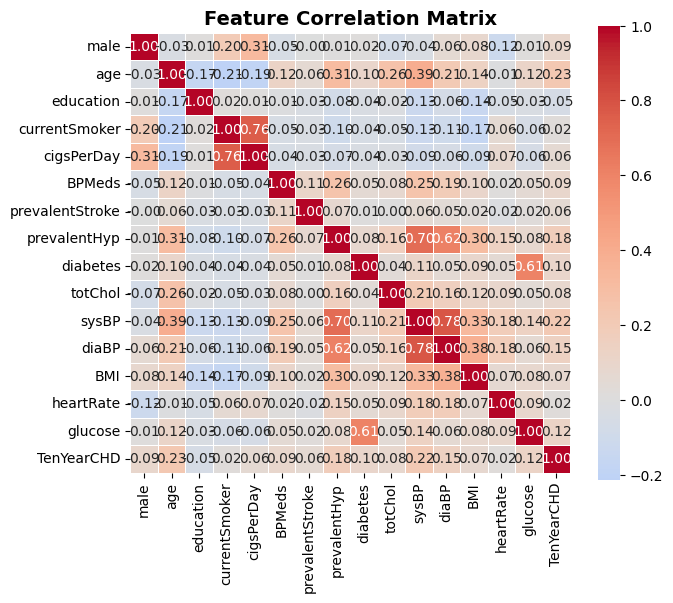

In [4]:
# Build feature correlation matrix to understand relationships between features and target variable
correlation_matrix = df_processed.corr()

target_corr = correlation_matrix['TenYearCHD'].sort_values(ascending=False)
print(target_corr)

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()

# **Feature Engineering**

In [5]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
X_train.to_csv('data/interim/X_train.csv', index=False)
y_train.to_csv('data/interim/y_train.csv', index=False)
X_test.to_csv('data/interim/X_test.csv', index=False)
y_test.to_csv('data/interim/y_test.csv', index=False)